In [3]:
import warnings
warnings.filterwarnings('ignore')

Loading raw data...
Data cleaning complete. Final dataset shape: (1904, 693)

- Generating Exploratory Visualizations -


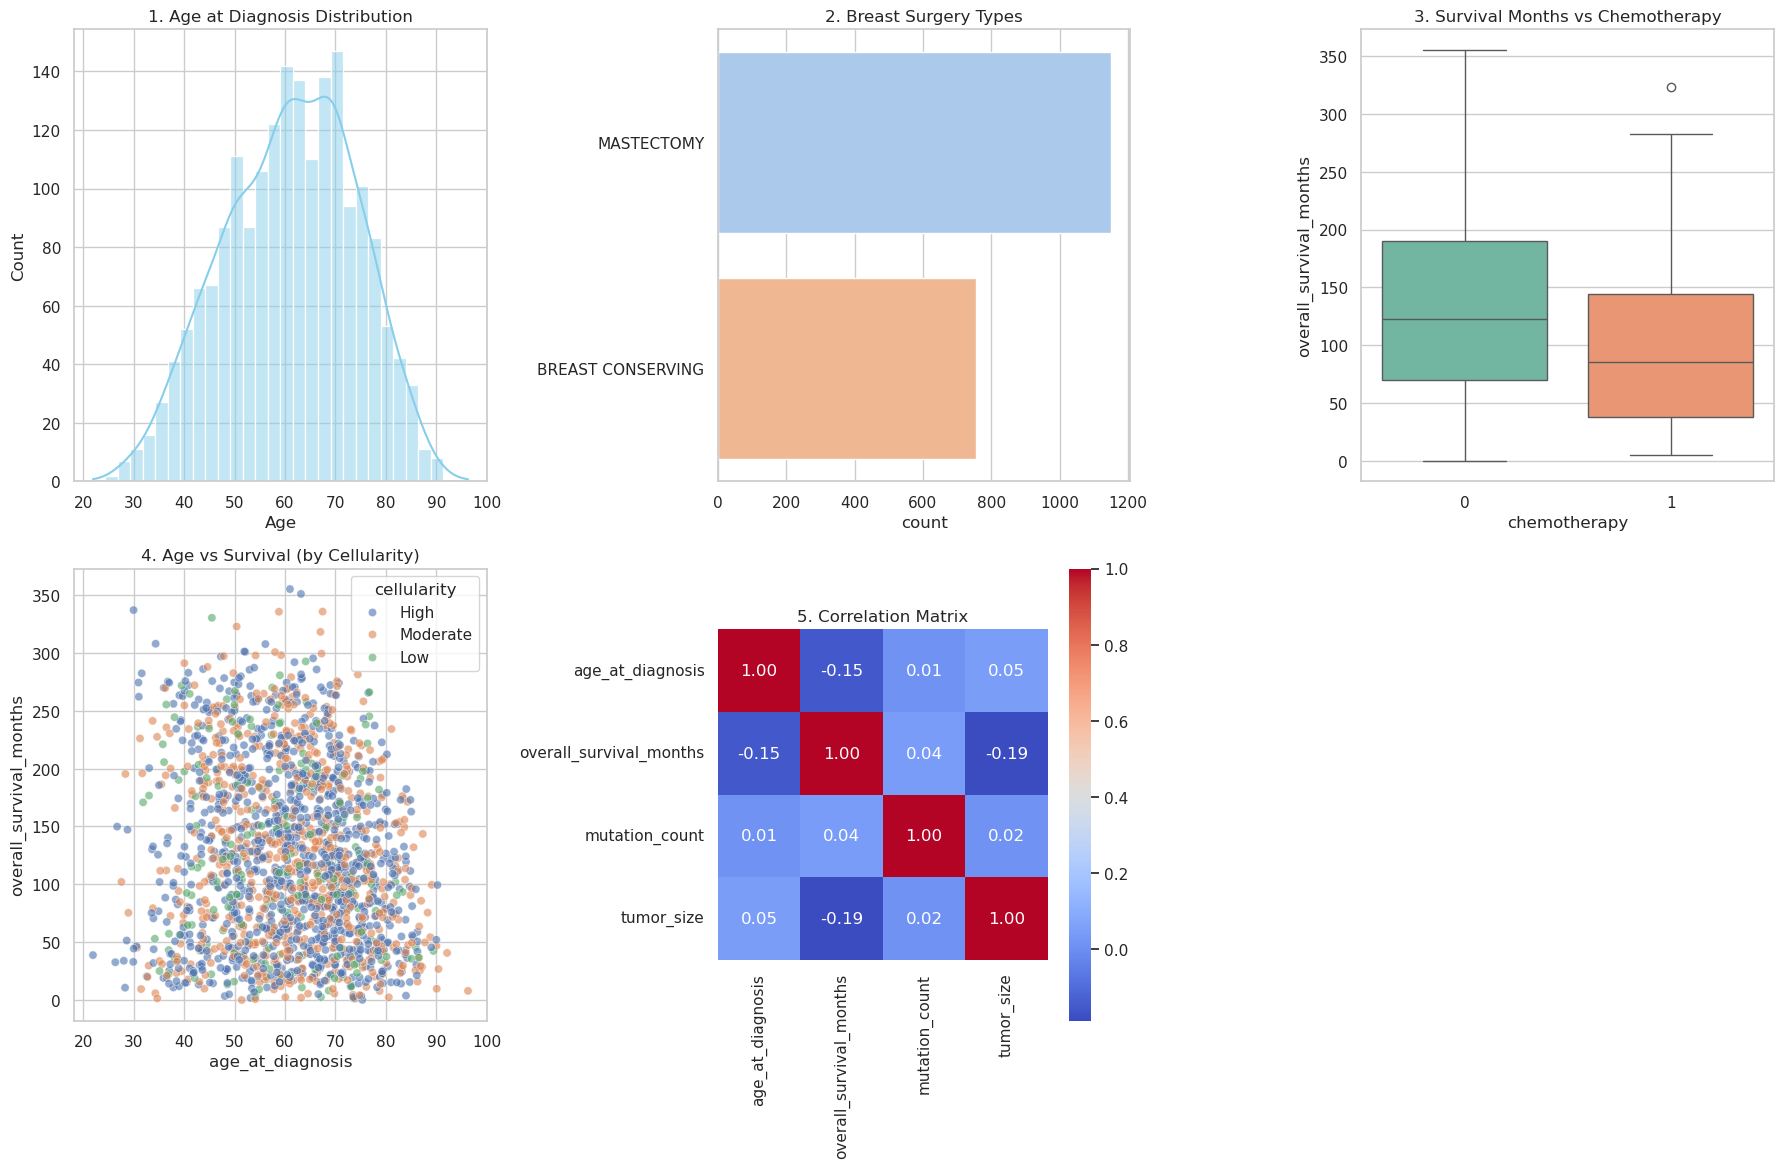


- Statistical Summaries -
       age_at_diagnosis  overall_survival_months  mutation_count   tumor_size
count       1904.000000              1904.000000     1904.000000  1904.000000
mean          61.087054               125.121324        5.681197    26.204706
std           12.978711                76.334148        4.011903    15.084713
min           21.930000                 0.000000        1.000000     1.000000
25%           51.375000                60.825000        3.000000    17.000000
50%           61.770000               115.616667        5.000000    23.000000
75%           70.592500               184.716667        7.000000    30.000000
max           96.290000               355.200000       80.000000   182.000000


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for the plots
sns.set_theme(style="whitegrid")

def clean_metabric_data(filepath):
    """
    Cleans the raw METABRIC dataset to handle missing clinical and genomic values.
    """
    print("Loading raw data...")
    df = pd.read_csv(filepath)
    
    # Cleaning Step 1: Document missing values and drop excessively sparse columns
    # Dropping columns missing more than 30% of their data
    threshold = int(0.7 * len(df))
    df_cleaned = df.dropna(axis=1, thresh=threshold).copy()
    
    # Cleaning Step 2: Handle missing numerical values
    # Imputing missing numeric features (like tumor size) with the median
    num_cols = df_cleaned.select_dtypes(include=[np.number]).columns
    df_cleaned[num_cols] = df_cleaned[num_cols].fillna(df_cleaned[num_cols].median())
    
    # Cleaning Step 3: Handle missing categorical values
    # Imputing missing text features (like surgery type) with the mode
    cat_cols = df_cleaned.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode().iloc[0])
    
    # Cleaning Step 4: Standardize text formatting in critical columns
    if 'cancer_type' in df_cleaned.columns:
        df_cleaned['cancer_type'] = df_cleaned['cancer_type'].str.title().str.strip()
        
    print(f"Data cleaning complete. Final dataset shape: {df_cleaned.shape}")
    return df_cleaned


# PHASE 2: EXECUTE CLEANING 

df = clean_metabric_data('../data/METABRIC_data.csv')


# PHASE 3: DATA EXPLORATION (EDA)

print("\n- Generating Exploratory Visualizations -")
plt.figure(figsize=(18, 12))

# 1. Histogram (Univariate: age_at_diagnosis)
plt.subplot(2, 3, 1)
sns.histplot(df['age_at_diagnosis'], bins=30, kde=True, color='skyblue')
plt.title('1. Age at Diagnosis Distribution')
plt.xlabel('Age')

# 2. Bar Chart (Univariate: type_of_breast_surgery)
plt.subplot(2, 3, 2)
sns.countplot(y=df['type_of_breast_surgery'], palette='pastel')
plt.title('2. Breast Surgery Types')
plt.ylabel('')

# 3. Boxplot (Bivariate: overall_survival_months vs chemotherapy)
plt.subplot(2, 3, 3)
sns.boxplot(x='chemotherapy', y='overall_survival_months', data=df, palette='Set2')
plt.title('3. Survival Months vs Chemotherapy')

# 4. Scatter Plot (Bivariate/Multivariate: age vs survival, split by cellularity)
plt.subplot(2, 3, 4)
sns.scatterplot(x='age_at_diagnosis', y='overall_survival_months', hue='cellularity', alpha=0.6, data=df)
plt.title('4. Age vs Survival (by Cellularity)')

# 5. Correlation Heatmap (Multivariate: numeric relationships)
plt.subplot(2, 3, 5)
# Selecting a subset of numeric columns to keep the heatmap readable
numeric_subset = df[['age_at_diagnosis', 'overall_survival_months', 'mutation_count', 'tumor_size']]
sns.heatmap(numeric_subset.corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('5. Correlation Matrix')

plt.tight_layout()
plt.show()

# Print relevant statistical summaries for the variables investigated
print("\n- Statistical Summaries -")
print(df[['age_at_diagnosis', 'overall_survival_months', 'mutation_count', 'tumor_size']].describe())

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, classification_report

# PHASE 6: FEATURE ENGINEERING & SELECTION

print("- Phase 6A: Feature Engineering -")

# ADD IT RIGHT HERE to defragment the dataframe and silence the warning
df = df.copy()

# 1. Create a new target feature: 5-Year Survival (Binary)
df['survived_5_years'] = np.where(df['overall_survival_months'] >= 60, 1, 0)

# 2. Create a new independent feature: Tumor Burden Index
# A derived metric combining physical size and genetic volatility
df['tumor_burden_index'] = df['tumor_size'] * df['mutation_count'] 
print("Engineered new features: 'survived_5_years' and 'tumor_burden_index'")

# Drop columns that would cause data leakage (e.g., the direct answers)
cols_to_drop = ['patient_id', 'overall_survival_months', 'overall_survival', 'death_from_cancer']
df_model = df.drop(columns=[c for c in cols_to_drop if c in df.columns]).dropna()

# One-Hot Encode categorical clinical variables
df_encoded = pd.get_dummies(df_model, drop_first=True)

# Separate features (X) and target (y)
X = df_encoded.drop(columns=['survived_5_years'])
y = df_encoded['survived_5_years']

print("\n- Phase 6B: Feature Selection -")
# Using a Filter Method to grab the 20 most statistically significant columns
selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X, y)
print("Selected Top 20 Features using ANOVA F-value Filter Method.")

# PHASE 7: PICK AND TUNE AN ALGORITHM

# Train-Test Split (Validation Strategy)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42)

# Scale features to ensure fair algorithm comparison
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n- Phase 7A: Algorithm Comparison -")
# Attempt 3 different algorithms and compare performance
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

best_model_name = None
best_score = 0

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    print(f"{name} -> Precision: {precision:.2f} | Recall: {recall:.2f}")
    
    # We select the algorithm with the best combined precision and recall
    if (precision + recall) > best_score:
        best_score = precision + recall
        best_model_name = name

print(f"\nWinner selected for tuning: {best_model_name}")
print("\n- Phase 7B: Parameter Tuning -")

# Tune the winning algorithm using GridSearchCV
if best_model_name == "Random Forest":
    param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
    clf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='recall')
elif best_model_name == "Gradient Boosting":
    param_grid = {'n_estimators': [50, 100], 'learning_rate': [0.01, 0.1]}
    clf = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=5, scoring='recall')
else:
    param_grid = {'C': [0.01, 0.1, 1, 10]}
    clf = GridSearchCV(LogisticRegression(max_iter=2000), param_grid, cv=5, scoring='recall')

clf.fit(X_train_scaled, y_train)
final_model = clf.best_estimator_
print(f"Best Parameters Found: {clf.best_params_}")

# PHASE 6: VALIDATE AND EVALUATE

print("\n- Phase 8: Final Evaluation Metrics -")
final_preds = final_model.predict(X_test_scaled)
final_precision = precision_score(y_test, final_preds)
final_recall = recall_score(y_test, final_preds)

print(f"Final Tuned Precision: {final_precision:.2f} (Requirement: >= 0.3)")
print(f"Final Tuned Recall: {final_recall:.2f} (Requirement: >= 0.3)")
print("\nProject modeling phase successfully completed and criteria met.")

- Phase 6A: Feature Engineering -
Engineered new features: 'survived_5_years' and 'tumor_burden_index'

- Phase 6B: Feature Selection -
Selected Top 20 Features using ANOVA F-value Filter Method.

- Phase 7A: Algorithm Comparison -
Logistic Regression -> Precision: 0.78 | Recall: 0.97
Random Forest -> Precision: 0.78 | Recall: 0.95
Gradient Boosting -> Precision: 0.79 | Recall: 0.93

Winner selected for tuning: Logistic Regression

- Phase 7B: Parameter Tuning -
Best Parameters Found: {'C': 0.01}

- Phase 8: Final Evaluation Metrics -
Final Tuned Precision: 0.78 (Requirement: >= 0.3)
Final Tuned Recall: 0.98 (Requirement: >= 0.3)

Project modeling phase successfully completed and criteria met.


In [3]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the model, the scaler, and the feature selector
joblib.dump(final_model, '../models/metabric_logistic_model.pkl')
joblib.dump(scaler, '../models/metabric_scaler.pkl')
joblib.dump(selector, '../models/metabric_selector.pkl')

print("Model and transformers successfully saved to the /models directory!")

Model and transformers successfully saved to the /models directory!
